In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras.losses import MeanSquaredError

In [2]:
df = pd.read_csv(r"../../Dataset/NCA Preprocessed/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [3]:
import sys
sys.path.append("../../")
from preprocessing.data_preprocessor import DataPreprocessor

preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train.shape)


Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [4]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


In [5]:
clip_min = np.percentile(X_ic_train,0.05)
clip_max = np.percentile(X_ic_train,99.5)

In [6]:
def fgsm_attack(model, X_ic_test, X_context_test, y_test, epsilon = 0.05, clip_min=None, clip_max=None):
    X_ic_adv = tf.convert_to_tensor(X_ic_test)
    X_context_test = tf.convert_to_tensor(X_context_test)
    y_true = tf.convert_to_tensor(y_test)
    
    with tf.GradientTape() as tape:
        tape.watch(X_ic_adv)
        y_pred = model([X_ic_adv, X_context_test],training=False)
        loss = tf.keras.losses.MeanSquaredError()(y_true, y_pred)

    gradient = tape.gradient(loss, X_ic_adv)
    signed_grad = tf.sign(gradient)
    X_ic_adv = X_ic_adv + epsilon * signed_grad

    if clip_min is not None and clip_max is not None:
        X_ic_adv = tf.clip_by_value(X_ic_adv, clip_min, clip_max)

    return X_ic_adv.numpy()

In [7]:
def pgd_attack(model, X_ic_test, X_context_test, y_test, alpha = 0.01, epsilon = 0.05, num_iterations = 10, clip_min=None, clip_max=None):
    X_ic_adv = tf.convert_to_tensor(X_ic_test)
    X_context_test = tf.convert_to_tensor(X_context_test)
    y_true = tf.convert_to_tensor(y_test)
    
    for _ in range(num_iterations):
        with tf.GradientTape() as Tape:
            Tape.watch(X_ic_adv)
            y_pred = model([X_ic_adv, X_context_test], training=False)
            loss = tf.keras.losses.MeanSquaredError()(y_true, y_pred)
        gradient = Tape.gradient(loss, X_ic_adv)
        signed_grad = tf.sign(gradient)
        X_ic_adv = X_ic_adv + alpha * signed_grad
        if clip_min is not None and clip_max is not None:
            X_ic_adv = tf.clip_by_value(X_ic_adv, clip_min, clip_max)
        else:
            X_ic_adv = tf.clip_by_value(X_ic_adv, X_ic_test - epsilon, X_ic_test + epsilon)
    
    return X_ic_adv.numpy()

In [8]:
def candw_attack(model, X_ic_test, X_context_test, y_test, attack_weight = 1.0 , lr = 0.01, steps = 100, clip_min=None, clip_max=None):
    if clip_min is None or clip_max is None:
        clip_min = globals().get('clip_min')
        clip_max = globals().get('clip_max')
    X_ic_test = tf.convert_to_tensor(X_ic_test, dtype= tf.float32)
    X_context_test = tf.convert_to_tensor(X_context_test, dtype= tf.float32)
    y_test = tf.convert_to_tensor(y_test, dtype= tf.float32)
    y_test = tf.expand_dims(y_test, axis = -1)

    delta = tf.Variable(tf.zeros_like(X_ic_test), trainable=True)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for _ in range(steps):
        with tf.GradientTape() as Tape:
            X_ic_adv = X_ic_test + delta
            X_ic_adv = tf.clip_by_value(X_ic_adv, clip_min, clip_max)

            y_pred = model([X_ic_adv, X_context_test], training=False)

            mse = tf.reduce_mean(tf.keras.losses.MSE(y_test, y_pred))

            l2 = tf.reduce_mean(tf.reduce_sum(tf.square(delta), axis =[1,2]))

            loss = l2 - attack_weight * mse
        
        gradient = Tape.gradient(loss, delta)
        optimizer.apply_gradients([(gradient,delta)])

    X_ic_adv = tf.clip_by_value(X_ic_adv + delta, clip_min, clip_max)

    return X_ic_adv.numpy()

In [9]:
def jsma_attack(model, X_ic_test, X_context_test, y_test, epsilon=0.7, k=3, clip_min=None, clip_max=None):
    if clip_min is None or clip_max is None:
        clip_min = globals().get('clip_min')
        clip_max = globals().get('clip_max')
    X_ic_np = np.array(X_ic_test, dtype=np.float32)
    X_context_np = np.array(X_context_test, dtype=np.float32)
    y_np = np.array(y_test, dtype=np.float32)

    X_ic_adv = X_ic_np.copy()

    for i in range(X_ic_np.shape[0]):
        
        x_var = tf.Variable(X_ic_np[i:i+1], dtype=tf.float32)
        context_sample = tf.convert_to_tensor(X_context_np[i:i+1], dtype=tf.float32)
        y_true = tf.convert_to_tensor(y_np[i:i+1], dtype=tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(x_var)
            y_pred = model([x_var, context_sample], training=False)
            loss = tf.reduce_mean(tf.keras.losses.MSE(y_true, y_pred))

        gradient = tape.gradient(loss, x_var)
        if gradient is None:
            # Skip this sample if gradient couldn't be computed
            continue

        # Convert gradient to 1D numpy array aligned with timesteps
        grad_np = gradient.numpy().reshape(-1)

        # Saliency = absolute gradient magnitude per timestep
        saliency = np.abs(grad_np)
        
        # Pick top-k timesteps to perturb
        indices = np.argsort(saliency)[-k:]

        for idx in indices:
            # idx indexes the flattened timestep dimension; for shape (1, T, 1) flatten -> T
            X_ic_adv[i, idx, 0] += epsilon * np.sign(grad_np[idx])

    X_ic_adv = np.clip(X_ic_adv, clip_min, clip_max)

    return X_ic_adv

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def compute_attack_heatmap(
    model,
    attack_fn,
    X_ic_test,
    X_ctx_test,
    y_test,
    attack_strengths,
    iteration_steps,
    attack_type="pgd",
    clip_min=None,
    clip_max=None
):
    """
    Returns a 2D array:
    rows -> attack_strengths
    cols -> iteration_steps
    values -> MAE under attack
    """

    heatmap = np.zeros((len(attack_strengths), len(iteration_steps)))

    for i, strength in enumerate(attack_strengths):
        for j, steps in enumerate(iteration_steps):

            if attack_type == "fgsm":
                X_adv = attack_fn(
                    model,
                    X_ic_test,
                    X_ctx_test,
                    y_test,
                    epsilon=strength,
                    clip_min=clip_min,
                    clip_max=clip_max
                )

            elif attack_type == "pgd":
                X_adv = attack_fn(
                    model,
                    X_ic_test,
                    X_ctx_test,
                    y_test,
                    epsilon=strength,
                    alpha=strength / steps,
                    num_iterations=steps,
                    clip_min=clip_min,
                    clip_max=clip_max
                )

            elif attack_type == "cw":
                X_adv = attack_fn(
                    model,
                    X_ic_test,
                    X_ctx_test,
                    y_test,
                    attack_weight=strength,
                    steps=steps,
                    clip_min=clip_min,
                    clip_max=clip_max
                )

            elif attack_type == "jsma":
                X_adv = attack_fn(
                    model,
                    X_ic_test,
                    X_ctx_test,
                    y_test,
                    epsilon=strength,
                    k=steps,
                    clip_min=clip_min,
                    clip_max=clip_max
                )

            # Predictions
            y_pred = model([X_adv, X_ctx_test], training=False).numpy().flatten()
            y_true = y_test.flatten()

            y_pred_real = y_pred * y_std + y_mean
            y_true_real = y_true * y_std + y_mean

            heatmap[i, j] = mean_absolute_error(y_true_real, y_pred_real)

    return heatmap

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap(
    heatmap,
    x_labels,
    y_labels,
    title,
    vmin=None,
    vmax=None
):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap,
        annot=True,
        fmt=".4f",
        cmap="viridis",
        xticklabels=x_labels,
        yticklabels=y_labels,
        vmin=vmin,
        vmax=vmax
    )
    plt.xlabel("Iteration steps")
    plt.ylabel("Attack strength")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [15]:
import os

models_dir = '../../Models'

# Load normal trained models
cnn_normal = keras.models.load_model(os.path.join(models_dir, 'best_cnn.keras'))
cnn_gru_normal = keras.models.load_model(os.path.join(models_dir, 'best_cnn_gru.keras'))
cnn_lstm_normal = keras.models.load_model(os.path.join(models_dir, 'best_cnn_lstm.keras'))
meta_learner_normal = keras.models.load_model(os.path.join(models_dir, 'best_meta_learner.keras'))
rcn_normal = keras.models.load_model(os.path.join(models_dir, 'best_rcn.keras'))

# Load adversarially trained models
cnn_fgsm_trained = keras.models.load_model(os.path.join(models_dir, 'fgsm_trained_cnn.keras'))
cnn_gru_cw_trained = keras.models.load_model(os.path.join(models_dir, 'c&w_trained_cnn_gru.keras'))
cnn_lstm_jsma_trained = keras.models.load_model(os.path.join(models_dir, 'jsma_trained_cnn_lstm.keras'))
rcn_pgd_trained = keras.models.load_model(os.path.join(models_dir, 'pgd_trained_rcn.keras'))

print("All models loaded successfully.")

c:\Users\saman\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


All models loaded successfully.


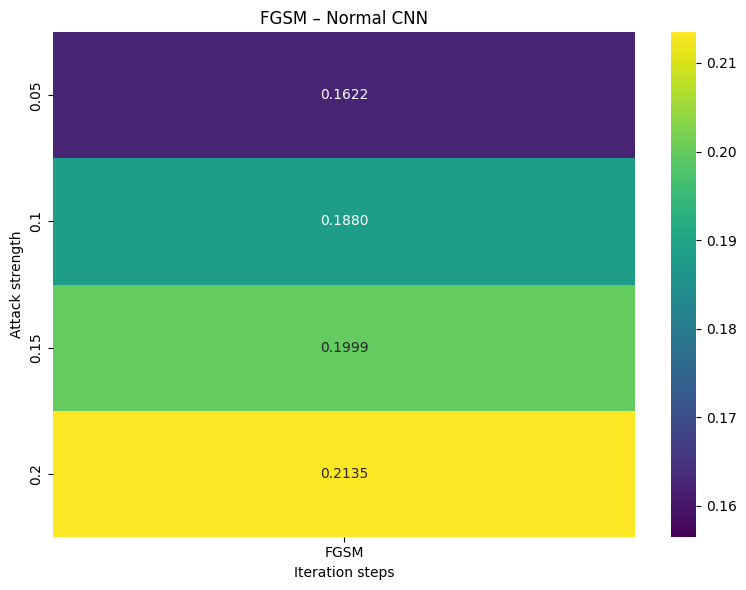

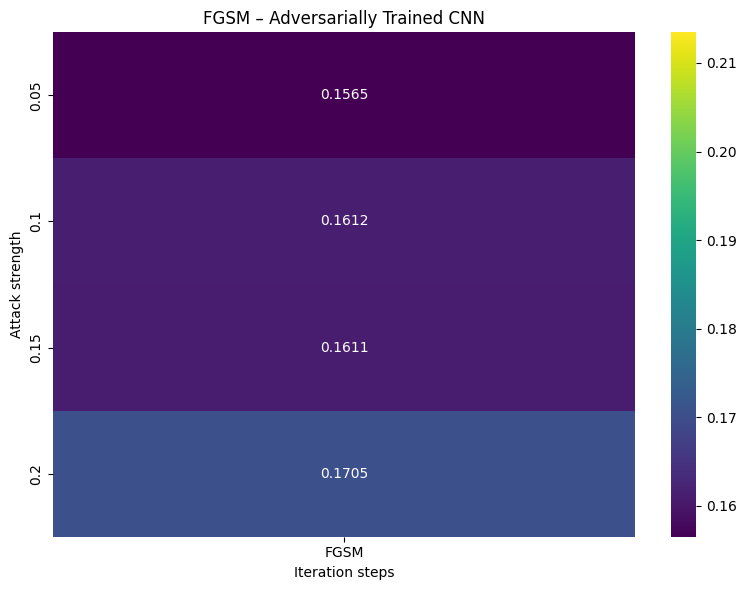

In [25]:
attack_strengths = [0.05, 0.1, 0.15, 0.2]
iteration_steps = [1]   # dummy

# Normal CNN
heatmap_normal = compute_attack_heatmap(
    model=cnn_normal,
    attack_fn=fgsm_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps,
    attack_type="fgsm",
    clip_min=clip_min,
    clip_max=clip_max
)

# Adversarially trained CNN
heatmap_adv = compute_attack_heatmap(
    model=cnn_fgsm_trained,
    attack_fn=fgsm_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps,
    attack_type="fgsm",
    clip_min=clip_min,
    clip_max=clip_max
)

# Same color scale for fair comparison
vmin = min(heatmap_normal.min(), heatmap_adv.min())
vmax = max(heatmap_normal.max(), heatmap_adv.max())

plot_heatmap(
    heatmap_normal,
    x_labels=["FGSM"],
    y_labels=attack_strengths,
    title="FGSM – Normal CNN",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    heatmap_adv,
    x_labels=["FGSM"],
    y_labels=attack_strengths,
    title="FGSM – Adversarially Trained CNN",
    vmin=vmin,
    vmax=vmax
)

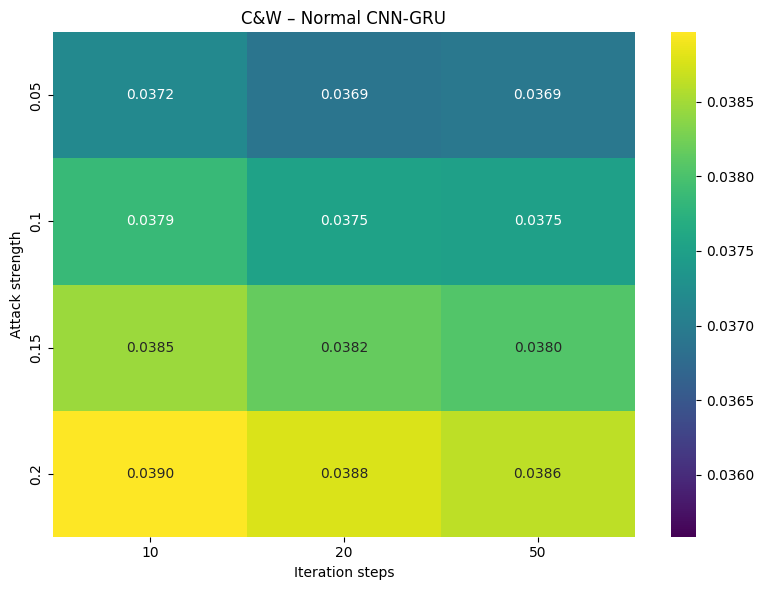

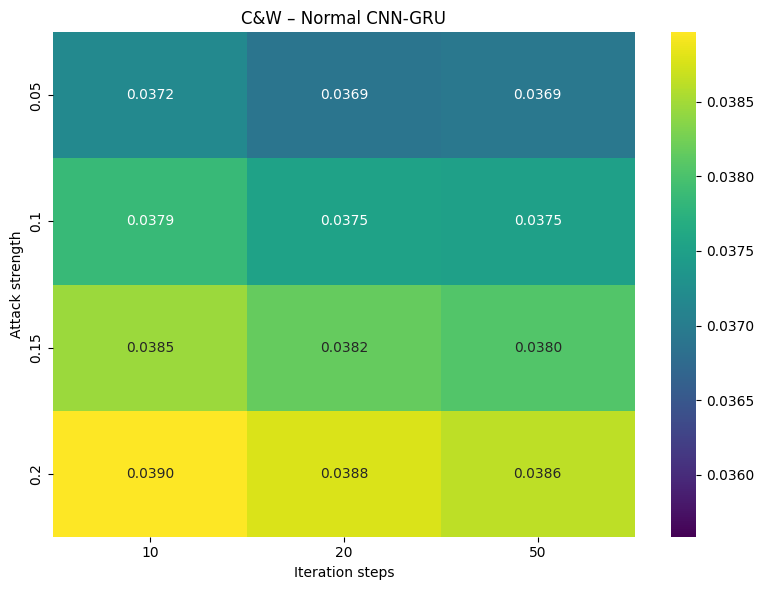

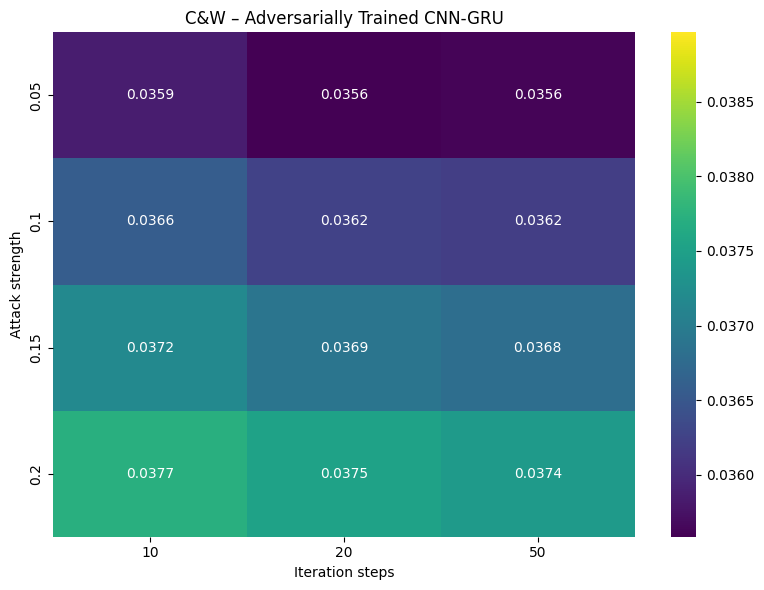

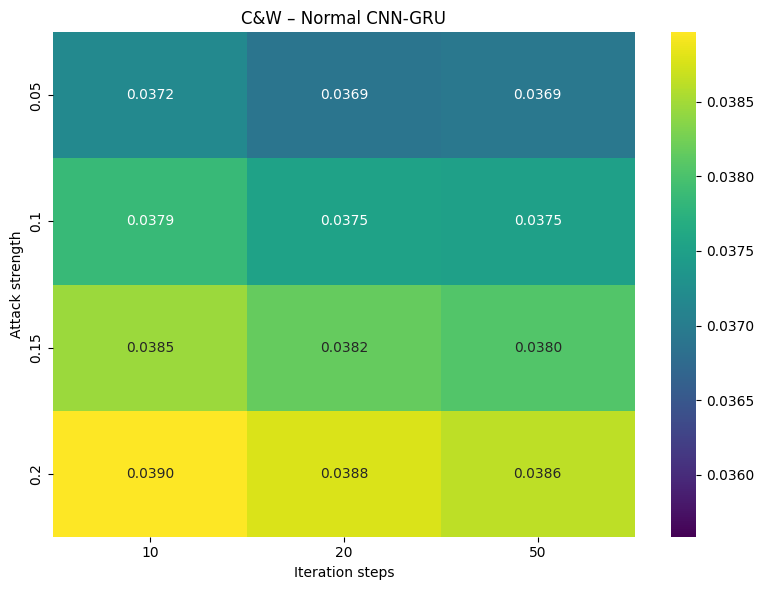

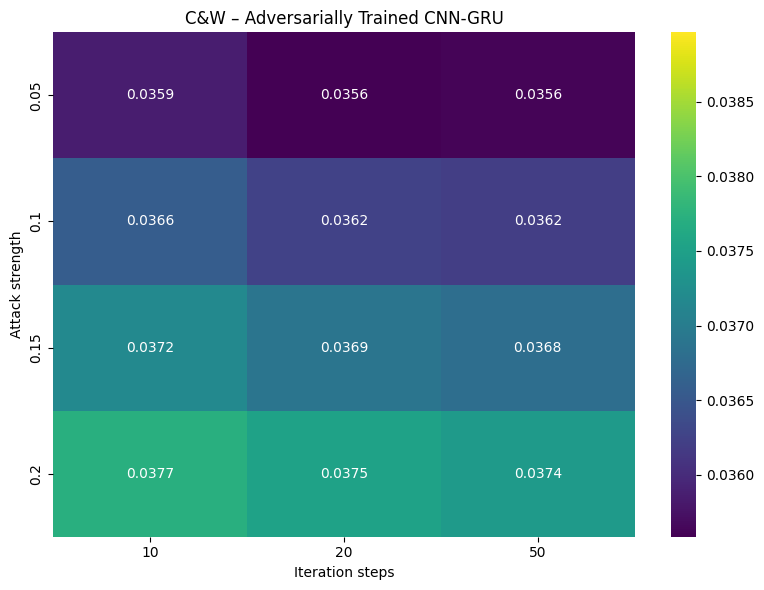

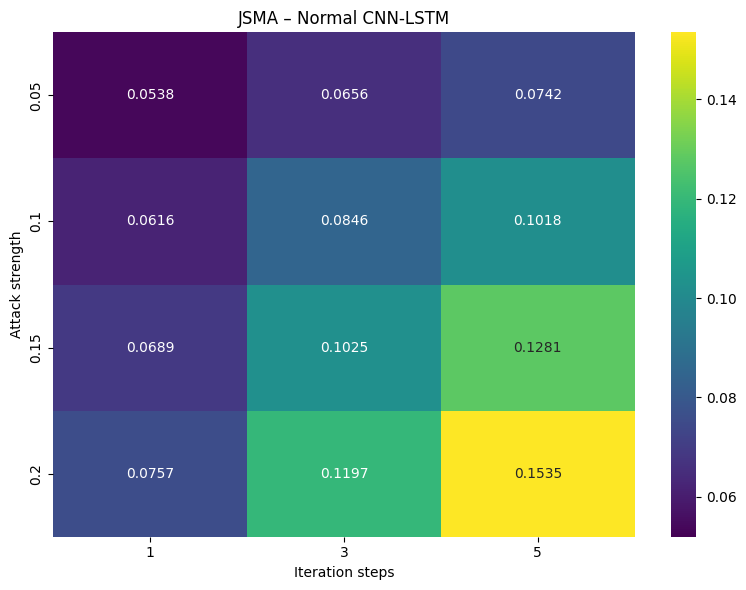

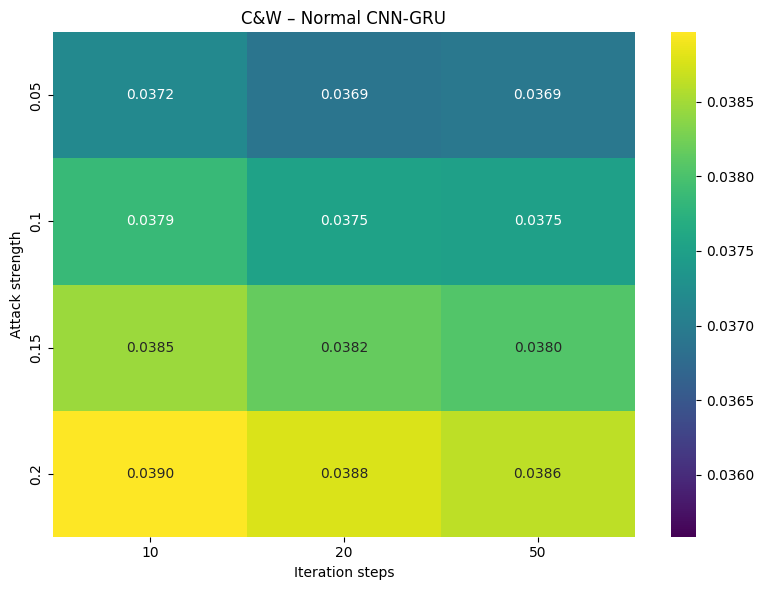

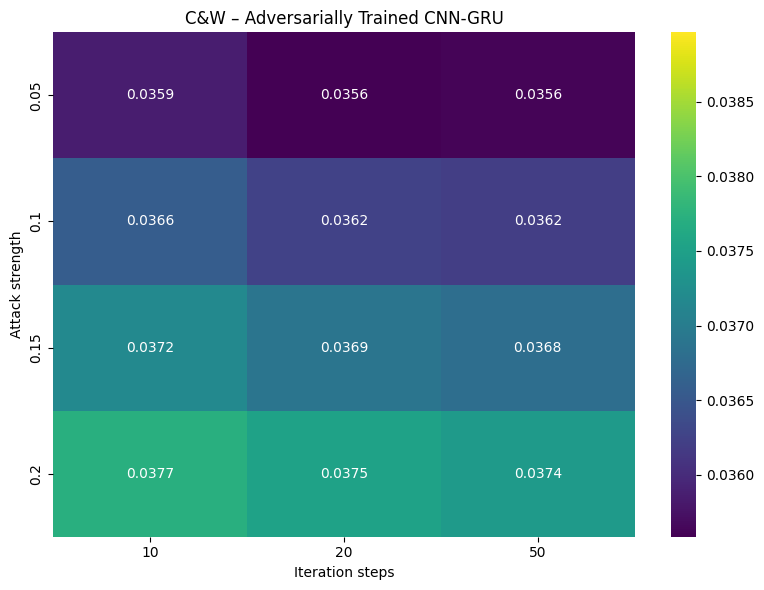

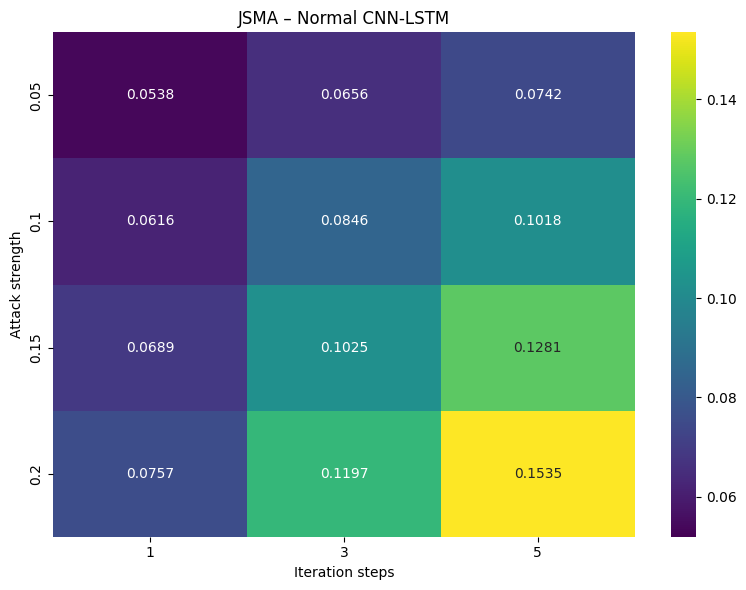

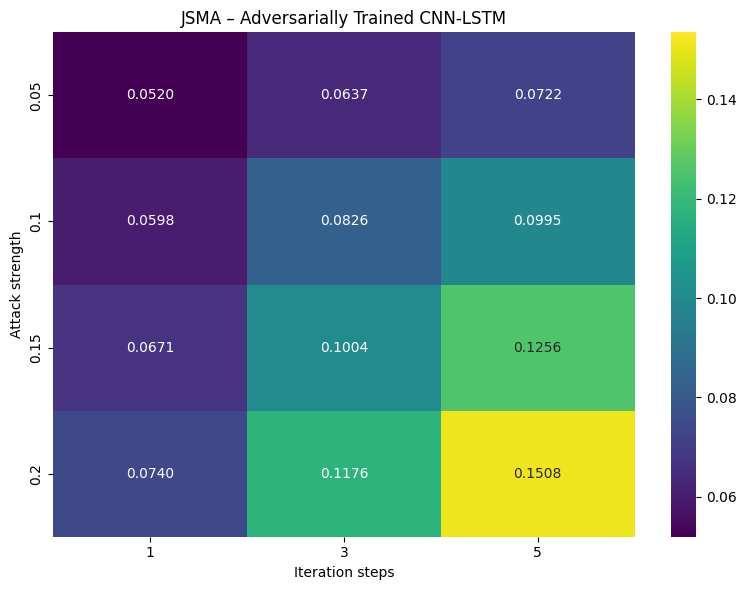

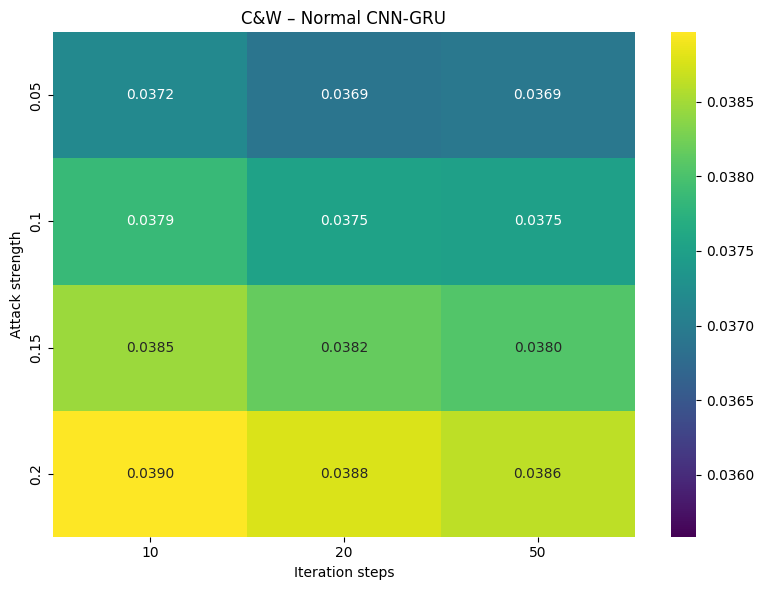

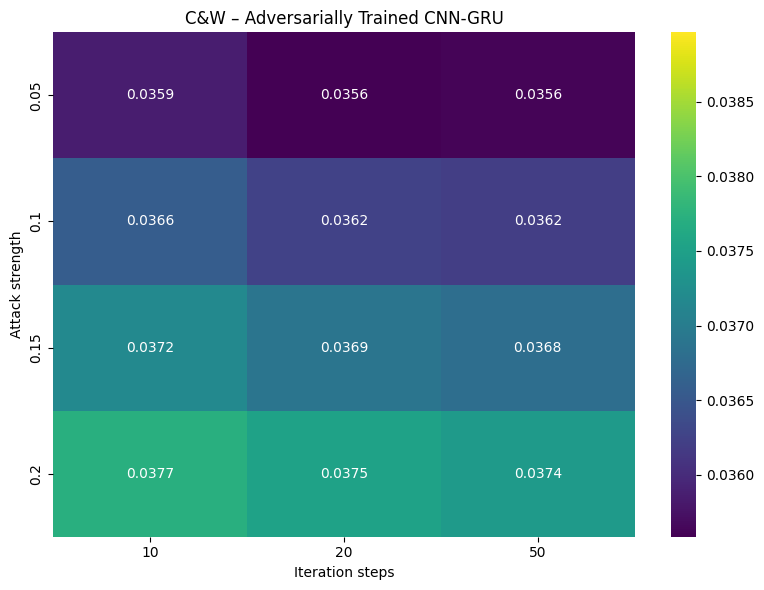

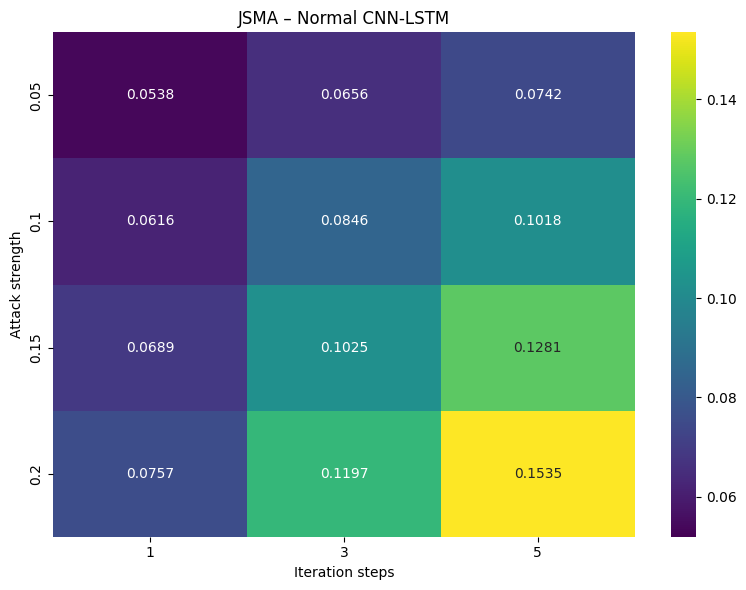

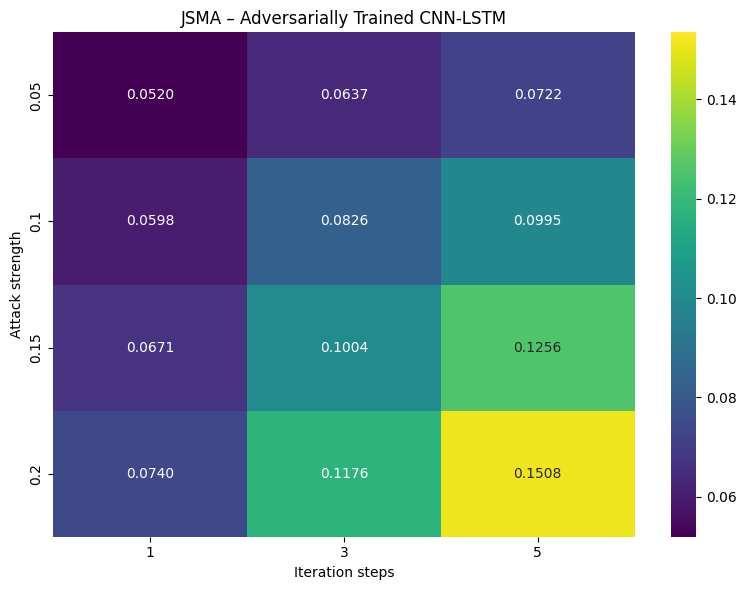

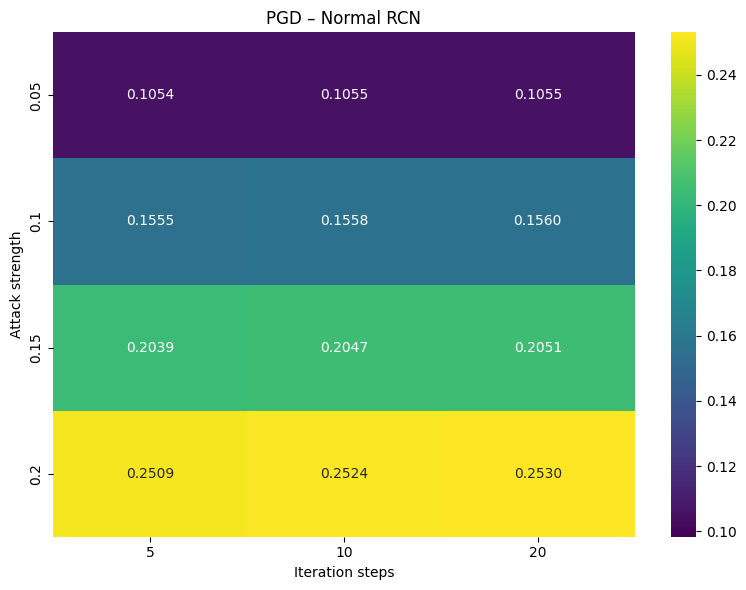

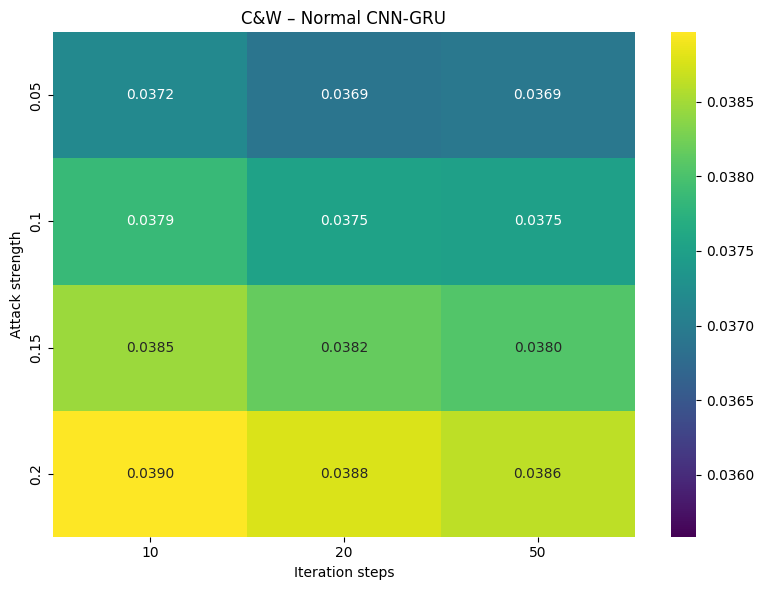

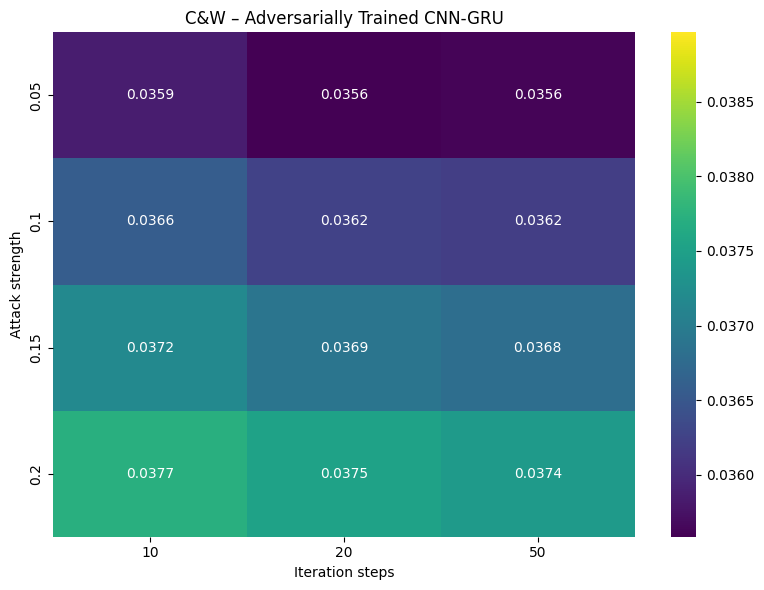

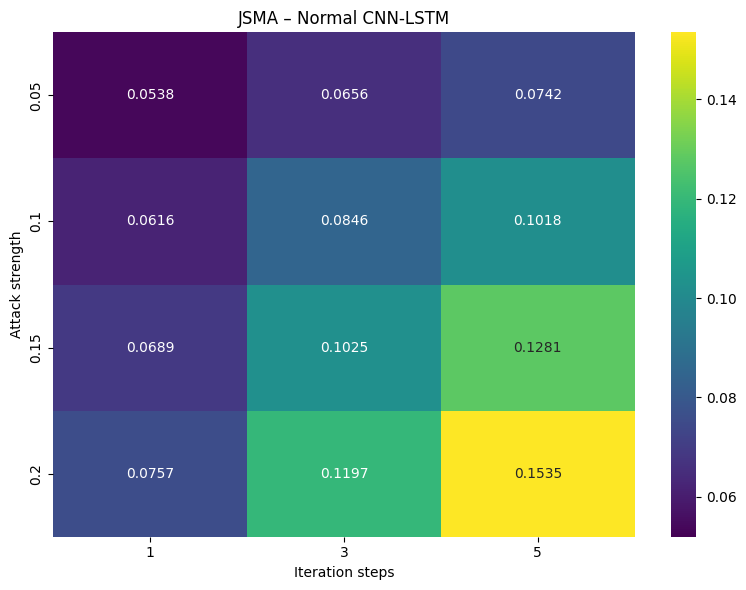

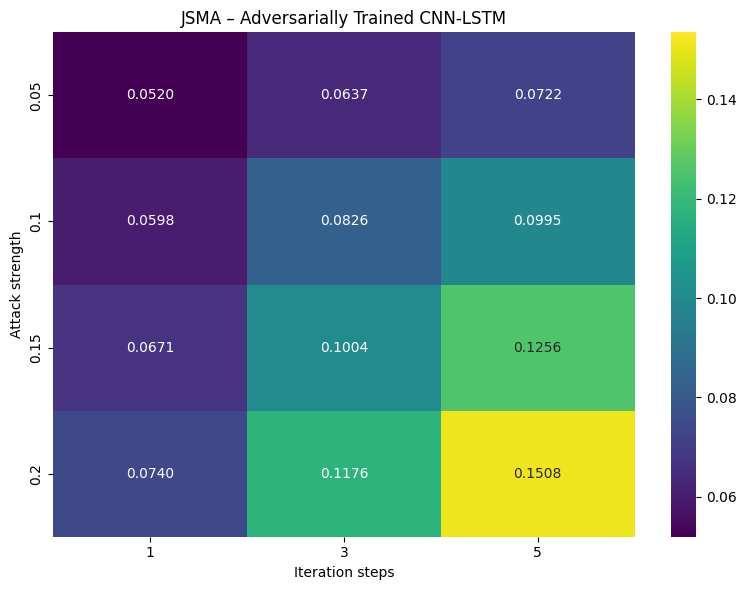

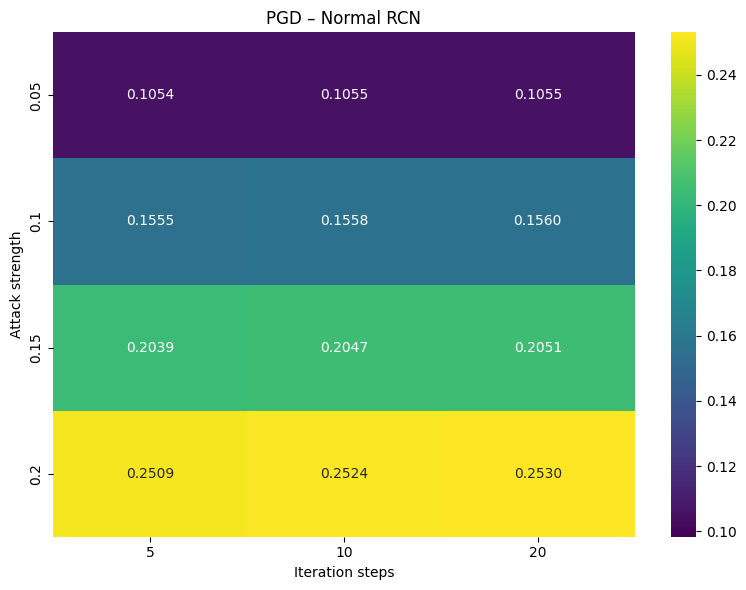

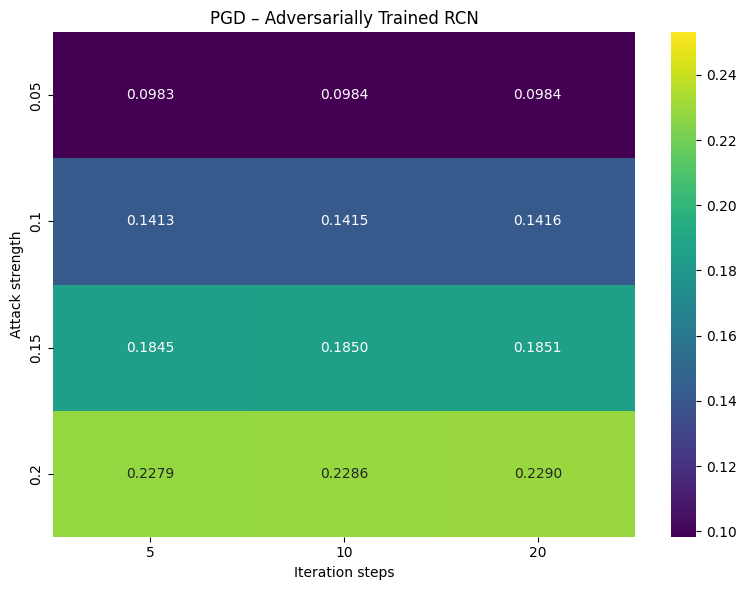

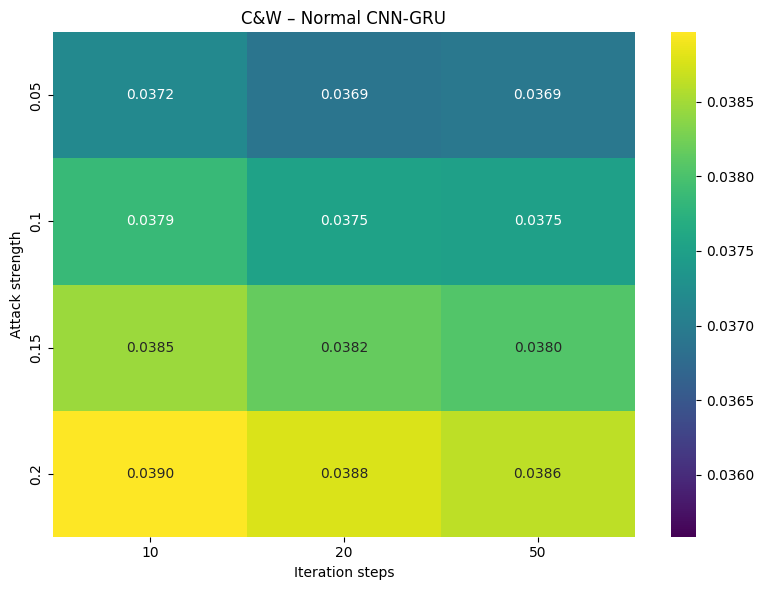

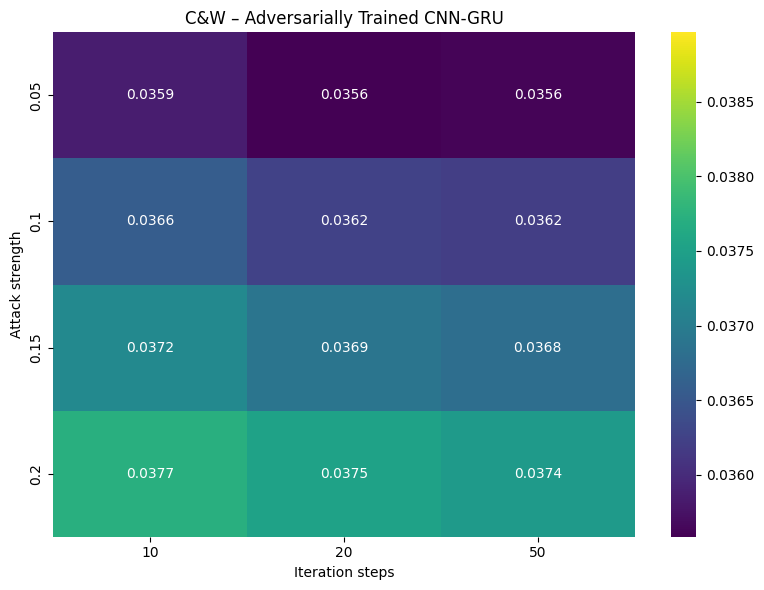

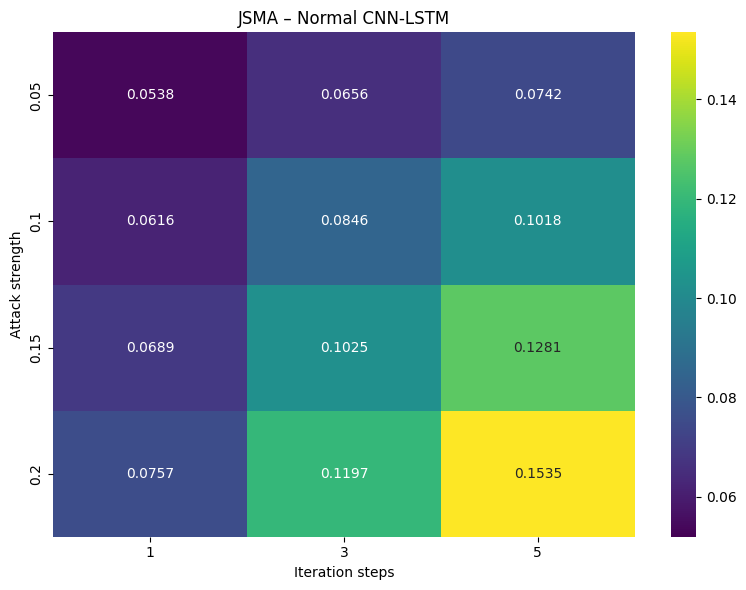

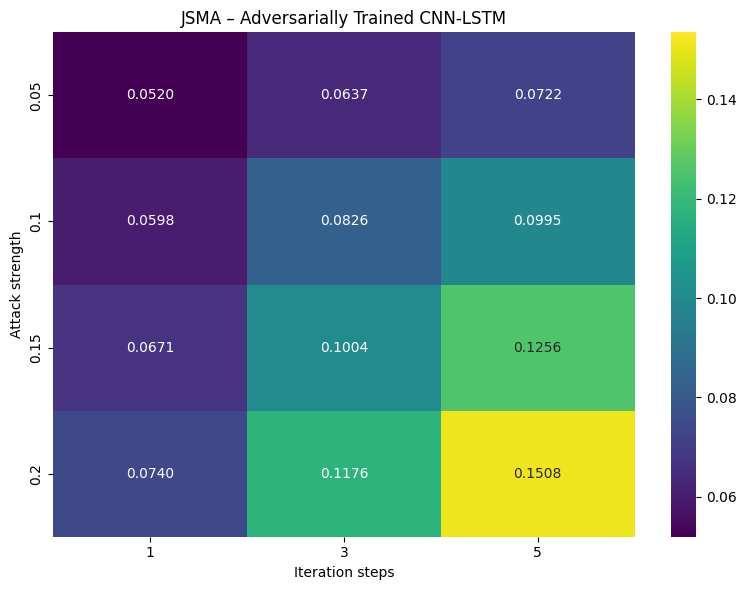

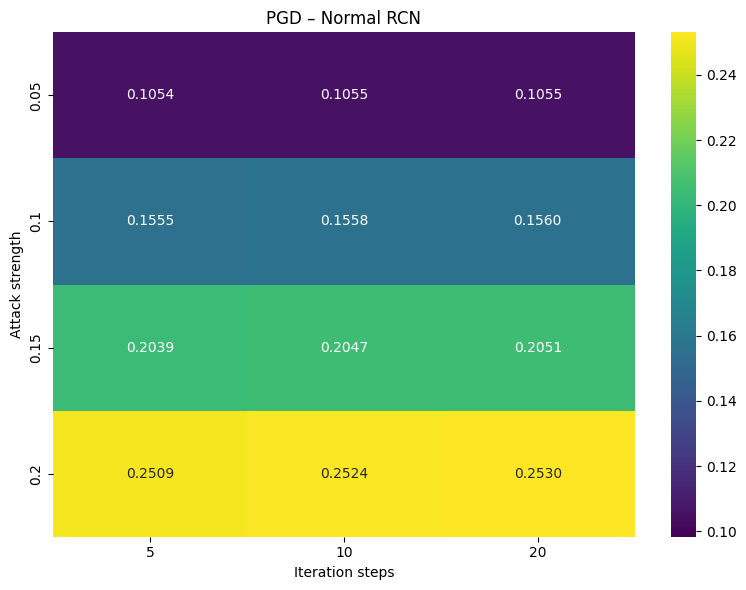

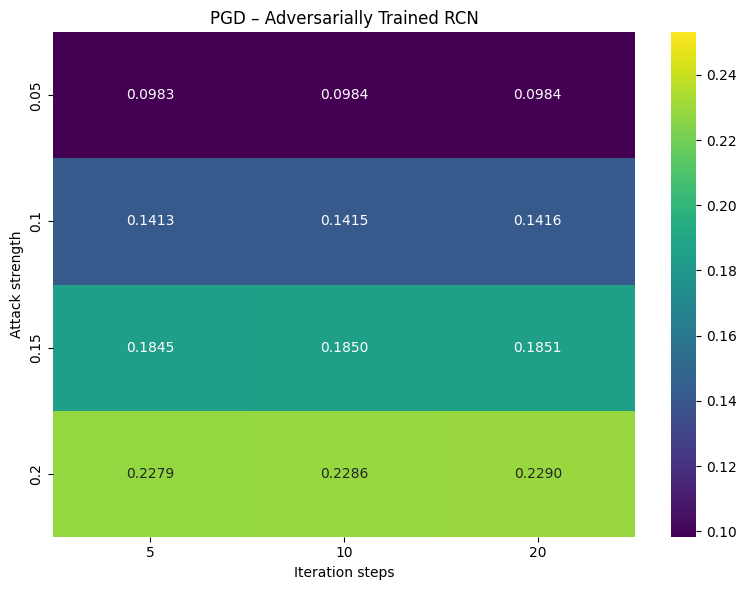

ValueError: Layer "functional_1" expects 1 input(s), but it received 2 input tensors. Inputs received: [<tf.Tensor: shape=(4528, 20, 1), dtype=float64, numpy=
array([[[-0.57316996],
        [-0.53334469],
        [-0.46815711],
        ...,
        [ 0.96406291],
        [ 1.07492313],
        [ 1.1380092 ]],

       [[-0.40891027],
        [-0.43428551],
        [-0.43597926],
        ...,
        [-0.64151879],
        [-0.79495909],
        [-0.91324283]],

       [[ 1.26517622],
        [ 1.01492373],
        [ 0.81193292],
        ...,
        [-0.13464044],
        [ 0.04512451],
        [ 0.19122532]],

       ...,

       [[-1.08702583],
        [-1.16574968],
        [-1.23718711],
        ...,
        [-0.55641649],
        [-0.67022603],
        [-0.85900578]],

       [[-0.60888881],
        [-0.69415709],
        [-0.75419753],
        ...,
        [-0.50098214],
        [-0.64713584],
        [-0.85029586]],

       [[ 1.44117433],
        [ 1.50746676],
        [ 1.55020

In [29]:
# CNN-GRU: C&W attack
iteration_steps_cw = [10, 20, 50]

heatmap_normal_gru = compute_attack_heatmap(
    model=cnn_gru_normal,
    attack_fn=candw_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps_cw,
    attack_type="cw",
    clip_min=clip_min,
    clip_max=clip_max
)

heatmap_adv_gru = compute_attack_heatmap(
    model=cnn_gru_cw_trained,
    attack_fn=candw_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps_cw,
    attack_type="cw",
    clip_min=clip_min,
    clip_max=clip_max
)

vmin_gru = min(heatmap_normal_gru.min(), heatmap_adv_gru.min())
vmax_gru = max(heatmap_normal_gru.max(), heatmap_adv_gru.max())

plot_heatmap(
    heatmap_normal_gru,
    x_labels=[str(s) for s in iteration_steps_cw],
    y_labels=attack_strengths,
    title="C&W – Normal CNN-GRU",
    vmin=vmin_gru,
    vmax=vmax_gru
)

plot_heatmap(
    heatmap_adv_gru,
    x_labels=[str(s) for s in iteration_steps_cw],
    y_labels=attack_strengths,
    title="C&W – Adversarially Trained CNN-GRU",
    vmin=vmin_gru,
    vmax=vmax_gru
)

# CNN-LSTM: JSMA attack
iteration_steps_jsma = [1, 3, 5]

heatmap_normal_lstm = compute_attack_heatmap(
    model=cnn_lstm_normal,
    attack_fn=jsma_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps_jsma,
    attack_type="jsma",
    clip_min=clip_min,
    clip_max=clip_max
)

heatmap_adv_lstm = compute_attack_heatmap(
    model=cnn_lstm_jsma_trained,
    attack_fn=jsma_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps_jsma,
    attack_type="jsma",
    clip_min=clip_min,
    clip_max=clip_max
)

vmin_lstm = min(heatmap_normal_lstm.min(), heatmap_adv_lstm.min())
vmax_lstm = max(heatmap_normal_lstm.max(), heatmap_adv_lstm.max())

plot_heatmap(
    heatmap_normal_lstm,
    x_labels=[str(s) for s in iteration_steps_jsma],
    y_labels=attack_strengths,
    title="JSMA – Normal CNN-LSTM",
    vmin=vmin_lstm,
    vmax=vmax_lstm
)

plot_heatmap(
    heatmap_adv_lstm,
    x_labels=[str(s) for s in iteration_steps_jsma],
    y_labels=attack_strengths,
    title="JSMA – Adversarially Trained CNN-LSTM",
    vmin=vmin_lstm,
    vmax=vmax_lstm
)

# RCN: PGD attack
iteration_steps_pgd = [5, 10, 20]

heatmap_normal_rcn = compute_attack_heatmap(
    model=rcn_normal,
    attack_fn=pgd_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps_pgd,
    attack_type="pgd",
    clip_min=clip_min,
    clip_max=clip_max
)

heatmap_adv_rcn = compute_attack_heatmap(
    model=rcn_pgd_trained,
    attack_fn=pgd_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps_pgd,
    attack_type="pgd",
    clip_min=clip_min,
    clip_max=clip_max
)

vmin_rcn = min(heatmap_normal_rcn.min(), heatmap_adv_rcn.min())
vmax_rcn = max(heatmap_normal_rcn.max(), heatmap_adv_rcn.max())

plot_heatmap(
    heatmap_normal_rcn,
    x_labels=[str(s) for s in iteration_steps_pgd],
    y_labels=attack_strengths,
    title="PGD – Normal RCN",
    vmin=vmin_rcn,
    vmax=vmax_rcn
)

plot_heatmap(
    heatmap_adv_rcn,
    x_labels=[str(s) for s in iteration_steps_pgd],
    y_labels=attack_strengths,
    title="PGD – Adversarially Trained RCN",
    vmin=vmin_rcn,
    vmax=vmax_rcn
)

# Meta Learner: FGSM attack (no adversarial trained version)
heatmap_meta = compute_attack_heatmap(
    model=meta_learner_normal,
    attack_fn=fgsm_attack,
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    attack_strengths=attack_strengths,
    iteration_steps=iteration_steps,
    attack_type="fgsm",
    clip_min=clip_min,
    clip_max=clip_max
)

plot_heatmap(
    heatmap_meta,
    x_labels=["FGSM"],
    y_labels=attack_strengths,
    title="FGSM – Meta Learner (Normal)",
    vmin=None,
    vmax=None
)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

def eval_under_attack(
    model,
    attack_fn,
    X_ic_test,
    X_ctx_test,
    y_test,
    attack_params,
    clip_min,
    clip_max,
    attack_type
):
    # Clean
    y_true = y_test.flatten()
    y_clean = model([X_ic_test, X_ctx_test], training=False).numpy().flatten()

    y_clean_true = y_clean * y_std + y_mean
    y_true_true = y_true * y_std + y_mean
    mae_clean = mean_absolute_error(y_true_true, y_clean_true)

    # Attack
    if attack_type == "fgsm":
        X_adv = attack_fn(
            model, X_ic_test, X_ctx_test, y_test,
            epsilon=attack_params["epsilon"],
            clip_min=clip_min, clip_max=clip_max
        )

    elif attack_type == "pgd":
        X_adv = attack_fn(
            model, X_ic_test, X_ctx_test, y_test,
            epsilon=attack_params["epsilon"],
            alpha=attack_params["alpha"],
            num_iterations=attack_params["num_iterations"],
            clip_min=clip_min, clip_max=clip_max
        )

    elif attack_type == "cw":
        X_adv = attack_fn(
            model, X_ic_test, X_ctx_test, y_test,
            attack_weight=attack_params["c"],
            steps=attack_params["steps"],
            clip_min=clip_min, clip_max=clip_max
        )

    elif attack_type == "jsma":
        X_adv = attack_fn(
            model, X_ic_test, X_ctx_test, y_test,
            epsilon=attack_params["epsilon"],
            k=attack_params["k"],
            clip_min=clip_min, clip_max=clip_max
        )

    y_adv = model([X_adv, X_ctx_test], training=False).numpy().flatten()

    y_adv_true = y_adv * y_std + y_mean

    mae_adv = mean_absolute_error(y_true_true, y_adv_true)
    delta_mae = mae_adv - mae_clean
    mape_adv = mean_absolute_percentage_error(y_true_true, y_adv_true)

    return mae_clean, mae_adv, delta_mae, mape_adv

In [13]:
from tabulate import tabulate

def robustness_table_single_setting(
    normal_model,
    adv_model,
    model_name,
    attack_fn,
    attack_params,
    attack_type,
    X_ic_test,
    X_ctx_test,
    y_test,
    clip_min,
    clip_max
):
    n_clean, n_adv, n_delta, n_mape = eval_under_attack(
        normal_model, attack_fn,
        X_ic_test, X_ctx_test, y_test,
        attack_params, clip_min, clip_max, attack_type
    )

    a_clean, a_adv, a_delta, a_mape = eval_under_attack(
        adv_model, attack_fn,
        X_ic_test, X_ctx_test, y_test,
        attack_params, clip_min, clip_max, attack_type
    )

    improvement_pct = ((n_delta - a_delta) / n_delta) * 100

    table = [
        ["Normal " + model_name, n_clean, n_adv, n_delta, n_mape, "—"],
        ["Adv-trained " + model_name, a_clean, a_adv, a_delta, a_mape, f"{improvement_pct:.2f}%"]
    ]

    headers = [
        "Model",
        "MAE (Clean)",
        "MAE (Attacked)",
        "ΔMAE",
        "MAPE (Attacked)",
        "Robustness Gain (%)"
    ]

    print(tabulate(table, headers=headers, floatfmt=".4f"))
    return improvement_pct

In [16]:
attack_params_fgsm = {
    "epsilon": 0.1
}

robustness_table_single_setting(
    normal_model=cnn_normal,
    adv_model=cnn_fgsm_trained,
    model_name="CNN",
    attack_fn=fgsm_attack,
    attack_params=attack_params_fgsm,
    attack_type="fgsm",
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    clip_min=clip_min,
    clip_max=clip_max
)

Model              MAE (Clean)    MAE (Attacked)    ΔMAE    MAPE (Attacked)  Robustness Gain (%)
---------------  -------------  ----------------  ------  -----------------  ---------------------
Normal CNN              0.5967            1.2495  0.6528             0.0144  —
Adv-trained CNN         0.7407            1.0719  0.3311             0.0125  49.27%


49.27453633248256

In [17]:
attack_params_pgd = {
    "epsilon": 0.1,
    "alpha": 0.01,
    "num_iterations": 10
}

robustness_table_single_setting(
    normal_model=rcn_normal,
    adv_model=rcn_pgd_trained,
    model_name="RCN",
    attack_fn=pgd_attack,
    attack_params=attack_params_pgd,
    attack_type="pgd",
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    clip_min=clip_min,
    clip_max=clip_max
)

Model              MAE (Clean)    MAE (Attacked)    ΔMAE    MAPE (Attacked)  Robustness Gain (%)
---------------  -------------  ----------------  ------  -----------------  ---------------------
Normal RCN              0.3568            1.0360  0.6792             0.0119  —
Adv-trained RCN         0.3693            0.9405  0.5712             0.0108  15.91%


15.908471343678896

In [21]:
attack_params_cw = {
    "c": 20,
    "steps": 100
}

robustness_table_single_setting(
    normal_model=cnn_gru_normal,
    adv_model=cnn_gru_cw_trained,
    model_name="CNN+GRU",
    attack_fn=candw_attack,
    attack_params=attack_params_cw,
    attack_type="cw",
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    clip_min=clip_min,
    clip_max=clip_max
)

Model                  MAE (Clean)    MAE (Attacked)    ΔMAE    MAPE (Attacked)  Robustness Gain (%)
-------------------  -------------  ----------------  ------  -----------------  ---------------------
Normal CNN+GRU              0.2326            9.4760  9.2434             0.1102  —
Adv-trained CNN+GRU         0.2256            9.5778  9.3522             0.1117  -1.18%


-1.1778140847217466

In [22]:
attack_params_jsma = {
    "epsilon": 0.1,
    "k": 1
}

robustness_table_single_setting(
    normal_model=cnn_lstm_normal,
    adv_model=cnn_lstm_jsma_trained,
    model_name="CNN+LSTM",
    attack_fn=jsma_attack,
    attack_params=attack_params_jsma,
    attack_type="jsma",
    X_ic_test=X_ic_test,
    X_ctx_test=X_context_test,
    y_test=y_test,
    clip_min=clip_min,
    clip_max=clip_max
)

Model                   MAE (Clean)    MAE (Attacked)    ΔMAE    MAPE (Attacked)  Robustness Gain (%)
--------------------  -------------  ----------------  ------  -----------------  ---------------------
Normal CNN+LSTM              0.2907            0.4097  0.1191             0.0047  —
Adv-trained CNN+LSTM         0.2836            0.3976  0.1140             0.0046  4.28%


4.283180844022355